In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/cleaned_featured_jobs.csv")

In [3]:
df.head()

,job_title,salary_estimate,job_description,rating,company_name,location,headquarters,size,founded,type_of_ownership,industry,sector,revenue,competitors,easy_apply,min_salary,max_salary,average_salary
0,"Data Analyst, Center on Immigration and Justic...",37-66,Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),NaN,True,37.0,66.0,51.5
1,Quality Data Analyst,37-66,Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),NaN,NaN,37.0,66.0,51.5
2,"Senior Data Analyst, Insights & Analytics Team...",37-66,We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,NaN,37.0,66.0,51.5
3,Data Analyst,37-66,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),NaN,NaN,37.0,66.0,51.5
4,Reporting Data Analyst,37-66,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True,37.0,66.0,51.5


In [4]:
print(df.columns.tolist())

['job_title', 'salary_estimate', 'job_description', 'rating', 'company_name', 'location', 'headquarters', 'size', 'founded', 'type_of_ownership', 'industry', 'sector', 'revenue', 'competitors', 'easy_apply', 'min_salary', 'max_salary', 'average_salary']


In [5]:
skills = [
    "Python",
    "SQL",
    "Excel",
    "Power BI",
    "Tableau",
    "Machine Learning",
    "Statistics",
    "Pandas",
    "NumPy",
    "R"
]

In [7]:
import re

skill_counts = {}

for skill in skills:

    if skill == "R":
        count = df["job_description"].str.contains(
            r"\bR\b",
            case=False,
            na=False,
            regex=True
        ).sum()

    else:
        count = df["job_description"].str.contains(
            re.escape(skill),
            case=False,
            na=False
        ).sum()

    skill_counts[skill] = count

print(skill_counts)

{'Python': np.int64(637), 'SQL': np.int64(1388), 'Excel': np.int64(1353), 'Power BI': np.int64(180), 'Tableau': np.int64(620), 'Machine Learning': np.int64(180), 'Statistics': np.int64(563), 'Pandas': np.int64(41), 'NumPy': np.int64(23), 'R': np.int64(441)}


In [8]:
skills_df = pd.DataFrame(
    list(skill_counts.items()),
    columns=["Skill", "Count"]
)

skills_df = skills_df.sort_values(
    by="Count",
    ascending=False
)

skills_df

,Skill,Count
1,SQL,1388
2,Excel,1353
0,Python,637
4,Tableau,620
6,Statistics,563
9,R,441
5,Machine Learning,180
3,Power BI,180
7,Pandas,41
8,NumPy,23


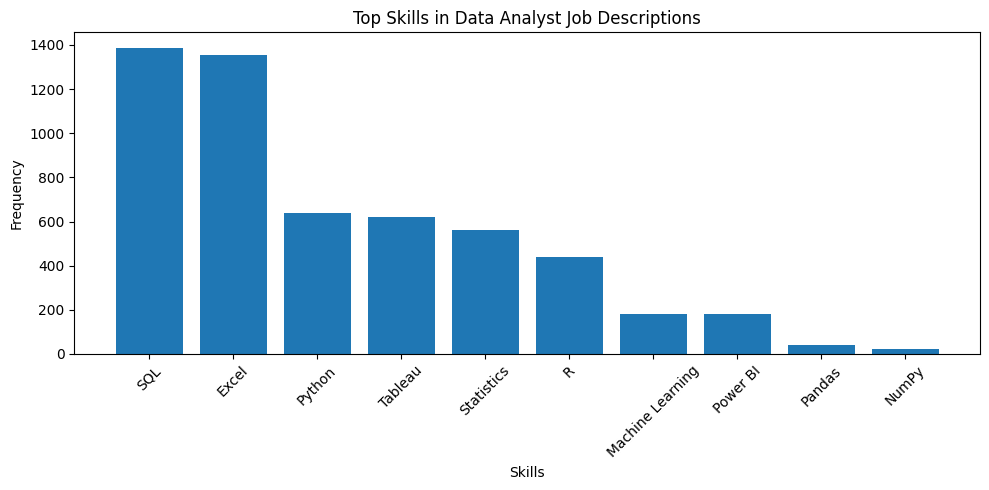

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(skills_df["Skill"], skills_df["Count"])

plt.title("Top Skills in Data Analyst Job Descriptions")
plt.xlabel("Skills")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../screenshots/skills_extraction.png")
plt.show()

In [10]:
skills_df.to_csv(
    "../data/extracted_skills.csv",
    index=False
)